<a href="https://colab.research.google.com/github/jasmine05102005/sugar/blob/main/Copy_of_sugar_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder,StandardScaler



In [ ]:
data = pd.read_excel('/content/Sugar_Prediction_Food.xlsx')
data.head()

,Fruit_Type,Weight (g),Moisture (%),Color_Index,Ripeness_Level,Acidity (pH),Temperature (°C),Sugar_Content (°Brix)
0,Strawberry,233.60,78.17,8.45,1,3.03,22.16,13.08
1,Orange,197.94,76.77,7.88,3,3.57,16.28,14.08
2,Mango,148.10,60.90,6.16,3,4.42,16.49,11.01
3,Strawberry,259.03,71.94,9.60,4,3.88,17.31,20.25
4,Grape,230.64,73.31,2.80,5,4.53,32.39,15.28


In [ ]:
data.isna().sum()

,0
Fruit_Type,0
Weight (g),0
Moisture (%),0
Color_Index,0
Ripeness_Level,0
Acidity (pH),0
Temperature (°C),0
Sugar_Content (°Brix),0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Fruit_Type             1000 non-null   object 
 1   Weight (g)             1000 non-null   float64
 2   Moisture (%)           1000 non-null   float64
 3   Color_Index            1000 non-null   float64
 4   Ripeness_Level         1000 non-null   int64  
 5   Acidity (pH)           1000 non-null   float64
 6   Temperature (°C)       1000 non-null   float64
 7   Sugar_Content (°Brix)  1000 non-null   float64
dtypes: float64(6), int64(1), object(1)
memory usage: 62.6+ KB


In [ ]:
data['Fruit_Type']=LabelEncoder().fit_transform(data['Fruit_Type'])

data.head()

,Fruit_Type,Weight (g),Moisture (%),Color_Index,Ripeness_Level,Acidity (pH),Temperature (°C),Sugar_Content (°Brix)
0,6,233.60,78.17,8.45,1,3.03,22.16,13.08
1,4,197.94,76.77,7.88,3,3.57,16.28,14.08
2,3,148.10,60.90,6.16,3,4.42,16.49,11.01
3,6,259.03,71.94,9.60,4,3.88,17.31,20.25
4,2,230.64,73.31,2.80,5,4.53,32.39,15.28


<Axes: >

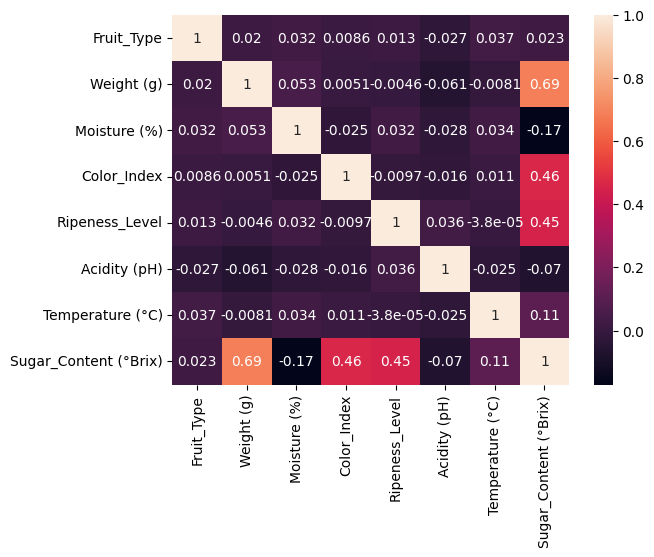

In [ ]:
sns.heatmap(data.corr(),annot=True)

In [ ]:
x=data.drop('Sugar_Content (°Brix)', axis=1)
y=data['Sugar_Content (°Brix)']
scaler=StandardScaler()
x=scaler.fit_transform(x)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)
print(x_train.shape,y_train.shape)
print(x_test.shape,y_test.shape)

(800, 7) (800,)
(200, 7) (200,)


In [ ]:
from xgboost import XGBRegressor
xgb = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
xgb.fit(x_train, y_train)
y_pred = xgb.predict(x_test)
print('Test MSE:', mean_squared_error(y_test, y_pred))

Test MSE: 1.6180813980187976


In [ ]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.9233625802564356

In [ ]:
modal=LinearRegression()
modal.fit(x_train,y_train)
y_pred=modal.predict(x_test)
print('Test MSE:', mean_squared_error(y_test, y_pred))
r2_score(y_test,y_pred)


Test MSE: 1.0309253855817067


0.9511721341115106

In [ ]:
from sklearn.ensemble import AdaBoostRegressor
abr=AdaBoostRegressor(n_estimators=100, random_state=42)
abr.fit(x_train, y_train)
y_pred = abr.predict(x_test)
print('Test MSE:', mean_squared_error(y_test, y_pred))
r2_score(y_test,y_pred)


Test MSE: 2.553546161256084


0.8790560294220274

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbr.fit(x_train, y_train)
y_pred = gbr.predict(x_test)
print('Test MSE:', mean_squared_error(y_test, y_pred))
r2_score(y_test,y_pred)


Test MSE: 1.4342885449849814


0.9320675873352304

In [ ]:
from sklearn.tree import DecisionTreeRegressor
crt = DecisionTreeRegressor()
crt.fit(x_train, y_train)
y_pred = crt.predict(x_test)
print('Test MSE:', mean_squared_error(y_test, y_pred))
r2_score(y_test,y_pred)

Test MSE: 4.0305675


0.8090996573593385